In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
data = pd .read_csv('BA_reviews.csv')
data.head()

,Unnamed: 0,reviews
0,0,✅ Trip Verified | Boarding was difficult caus...
1,1,✅ Trip Verified | Boarding started with a del...
2,2,✅ Trip Verified | Absolutely horrible custome...
3,3,Not Verified | BA is not what it used to be! ...
4,4,"✅ Trip Verified | BA First, it's not even the..."


In [64]:
data.shape

(1000, 2)

## Text Preprocessing

In [65]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer

In [66]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [67]:
data[['trip_verified', 'reviews']] = data['reviews'].str.split(r"\|", n=1, expand=True)

In [68]:
data

,Unnamed: 0,reviews,trip_verified
0,0,Boarding was difficult caused by vast majori...,✅ Trip Verified
1,1,Boarding started with a delay of some 20 min...,✅ Trip Verified
2,2,Absolutely horrible customer service - will ...,✅ Trip Verified
3,3,BA is not what it used to be! As much as I l...,Not Verified
4,4,"BA First, it's not even the best business cl...",✅ Trip Verified
...,...,...,...
995,995,London to Vancouver. Check in agent very hel...,✅ Trip Verified
996,996,The First Class zone at Heathrow T5 and the C...,✅ Trip Verified
997,997,I had a miserable experience in first class ...,✅ Trip Verified
998,998,Leeds Bradford to Las Vegas via Heathrow. Cu...,✅ Trip Verified


In [69]:
data.isnull().sum()

Unnamed: 0       0
reviews          0
trip_verified    0
dtype: int64

In [70]:
# Function for text preprocessing
def preprocess_text(text):

    text = text.lower()
    text = re.sub(r'\d+', '', text)

    sentences = sent_tokenize(text)
    preprocessed_sentences = []
    for sentence in sentences:
    
        sentence = re.sub(r'[^\w\s]', '', sentence)
    
        tokens = word_tokenize(sentence)
 
        stop_words = set(stopwords.words('english'))
        filtered_tokens = [word for word in tokens if word not in stop_words]
        lemmatizer = WordNetLemmatizer()
        lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

        preprocessed_sentence = ' '.join(lemmatized_tokens)
        preprocessed_sentences.append(preprocessed_sentence)

    preprocessed_text = ' '.join(preprocessed_sentences)
    return preprocessed_text

In [71]:
data['clean_reviews'] = data['reviews'].apply(preprocess_text)
data.drop(columns=['reviews'], inplace=True)

In [72]:
data

,Unnamed: 0,trip_verified,clean_reviews
0,0,✅ Trip Verified,boarding difficult caused vast majority passen...
1,1,✅ Trip Verified,boarding started delay minute everybody could ...
2,2,✅ Trip Verified,absolutely horrible customer service never fly...
3,3,Not Verified,ba used much like onboard crew check staff lac...
4,4,✅ Trip Verified,ba first even best business class sky cabin lo...
...,...,...,...
995,995,✅ Trip Verified,london vancouver check agent helpful searching...
996,996,✅ Trip Verified,first class zone heathrow concorde lounge good...
997,997,✅ Trip Verified,miserable experience first class london chicag...
998,998,✅ Trip Verified,leeds bradford la vega via heathrow customer s...


In [73]:
data.head()

,Unnamed: 0,trip_verified,clean_reviews
0,0,✅ Trip Verified,boarding difficult caused vast majority passen...
1,1,✅ Trip Verified,boarding started delay minute everybody could ...
2,2,✅ Trip Verified,absolutely horrible customer service never fly...
3,3,Not Verified,ba used much like onboard crew check staff lac...
4,4,✅ Trip Verified,ba first even best business class sky cabin lo...


In [74]:
data['trip_verified'] = data['trip_verified'].str.strip()
data['trip_verified'] = data['trip_verified'].map({'✅ Trip Verified': 'yes', 'Not Verified': 'no', '✅ Trip Verified ': 'yes'})

In [77]:
data.drop(columns=['Unnamed: 0'], inplace=True)
data

,trip_verified,clean_reviews
0,yes,boarding difficult caused vast majority passen...
1,yes,boarding started delay minute everybody could ...
2,yes,absolutely horrible customer service never fly...
3,no,ba used much like onboard crew check staff lac...
4,yes,ba first even best business class sky cabin lo...
...,...,...
995,yes,london vancouver check agent helpful searching...
996,yes,first class zone heathrow concorde lounge good...
997,yes,miserable experience first class london chicag...
998,yes,leeds bradford la vega via heathrow customer s...


## Visualization

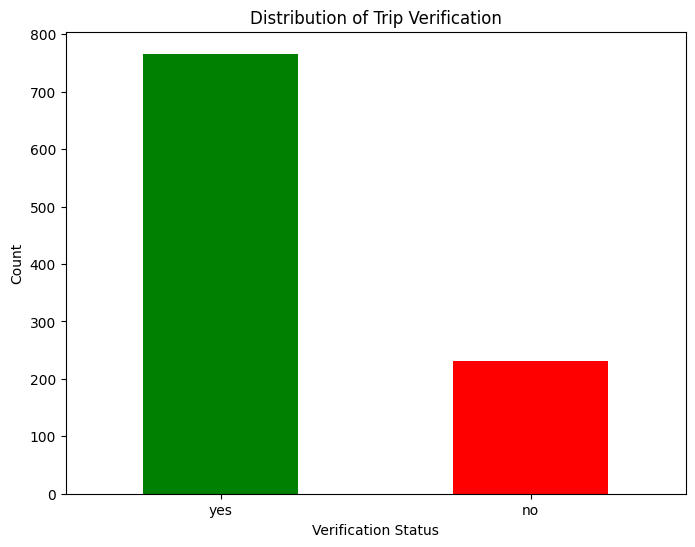

In [78]:
import matplotlib.pyplot as plt

# Visualize the distribution of 'trip_verified' column
plt.figure(figsize=(8, 6))
data['trip_verified'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of Trip Verification')
plt.xlabel('Verification Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

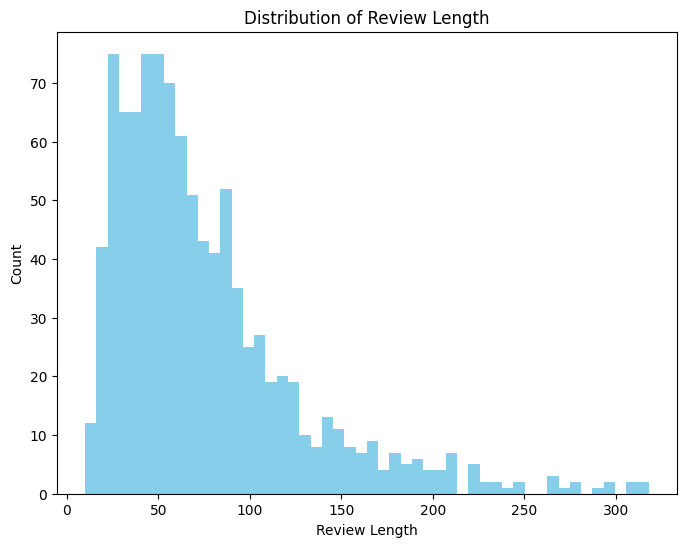

In [79]:
# Analyze the length of reviews
data['review_length'] = data['clean_reviews'].apply(lambda x: len(x.split()))

# Plot the distribution of review lengths
plt.figure(figsize=(8, 6))
plt.hist(data['review_length'], bins=50, color='skyblue')
plt.title('Distribution of Review Length')
plt.xlabel('Review Length')
plt.ylabel('Count')
plt.show()

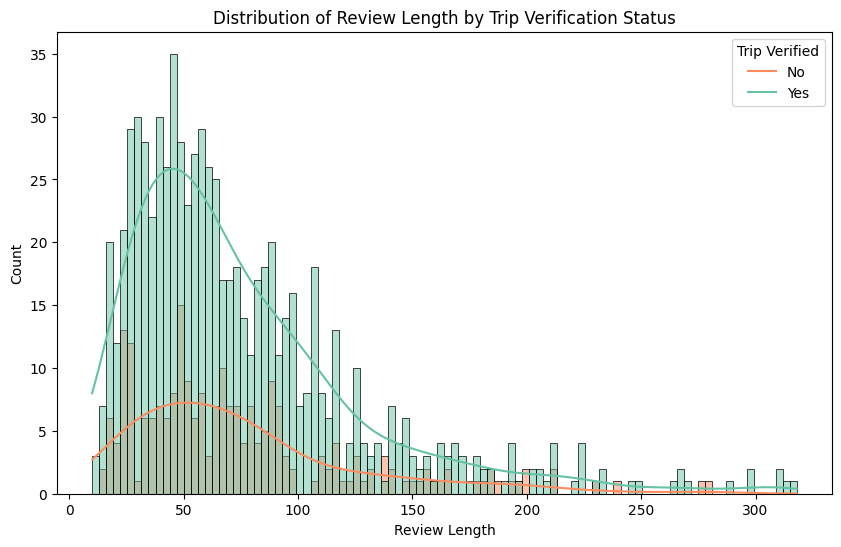

In [86]:
# Plot the distribution of review lengths based on trip verification status
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='review_length', hue='trip_verified', bins=100, kde=True, palette='Set2')
plt.title('Distribution of Review Length by Trip Verification Status')
plt.xlabel('Review Length')
plt.ylabel('Count')
plt.legend(title='Trip Verified', loc='upper right', labels=['No', 'Yes'])
plt.show()

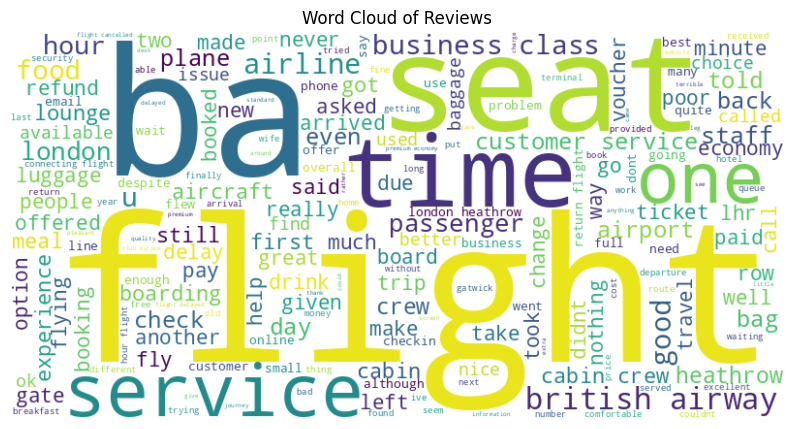

In [83]:
from wordcloud import WordCloud

# Combine all reviews into a single string
all_reviews = ' '.join(data['clean_reviews'])

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews)

# Plot the word cloud
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of Reviews')
plt.axis('off')
plt.show()

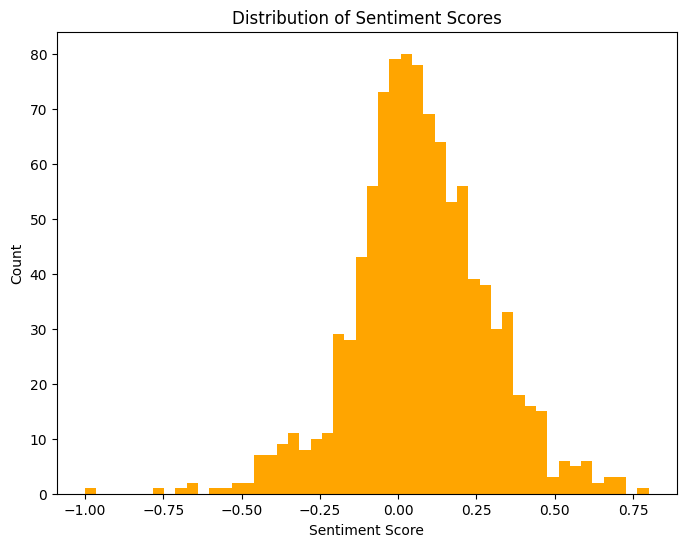

In [84]:
from textblob import TextBlob

# Perform sentiment analysis
data['sentiment'] = data['clean_reviews'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Plot the distribution of sentiment scores
plt.figure(figsize=(8, 6))
plt.hist(data['sentiment'], bins=50, color='orange')
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.show()

In [87]:
top_reviews = data.sort_values(by='sentiment', ascending=False)
top_reviews[['trip_verified', 'clean_reviews', 'sentiment']].head(10)

,trip_verified,clean_reviews,sentiment
401,yes,hour min flight given bag potato chip bottle w...,0.800000
847,yes,edinburgh kuala lumpur via london returned kl ...,0.716667
769,yes,gatwick st lucia great service flight thank mu...,0.700000
378,no,good flight apart seat fabric coming apart onj...,0.700000
9,yes,upgraded check club europe seat excellent expe...,0.686538
578,yes,crew denver airport top notch impressed custom...,0.675000
746,yes,stockholm london heathrow always ba work excel...,0.666667
951,yes,cabin crew flight ba london chennai efficient ...,0.633333
299,yes,organised boarding process really friendly cre...,0.627083
610,yes,fantastic flight heathrow crew best keep every...,0.616667


In [94]:
bad_reviews = data.sort_values(by='sentiment', ascending=True)
bad_reviews[['trip_verified', 'clean_reviews', 'sentiment']].head(10)

,trip_verified,clean_reviews,sentiment
139,yes,month passed still wasting time ba team sharin...,-1.000000
886,yes,mykonos london flight delayed waiting depart t...,-0.766667
122,no,worst service ever baggage arrive time flight ...,-0.700000
894,yes,stockholm london worst business class flight f...,-0.650000
495,no,food awful night early morning flight started ...,-0.642857
481,yes,ba continue charge premium disgusting service ...,-0.575000
32,no,paid business class travelling cairo london he...,-0.560000
510,yes,ba got wrong hour delay food voucher pound inf...,-0.500000
892,yes,flew yesterday heathrow manchester business cl...,-0.500000
669,yes,london city berlin th march flight got cancele...,-0.475000


In [95]:
bad_reviews_text = bad_reviews['clean_reviews'].head(10)
for index, review_text in enumerate(bad_reviews_text, 1):
    print(f"Review {index}:\n{review_text}\n")

Review 1:
month passed still wasting time ba team sharing document flight delhi london got delayed december missed connecting flight london heathrow vancouver ba put u flight hour reaching vancouver told baggage lost horrible experience customer relation person even look detail already shared december january april july

Review 2:
mykonos london flight delayed waiting depart time prepared miss connection take hour late staff worst airline may stuck runway wont offer water worst business class experience

Review 3:
worst service ever baggage arrive time flight delayed never fly even food bad service

Review 4:
stockholm london worst business class flight flown split seating wife apparently overbooked meal inedible worst airline meal served

Review 5:
food awful night early morning flight started offer terrible chicken wrap thing terrible went traditional breakfast disgusting sausage inedible hash brown rubbish ba

Review 6:
ba continue charge premium disgusting service provided people s

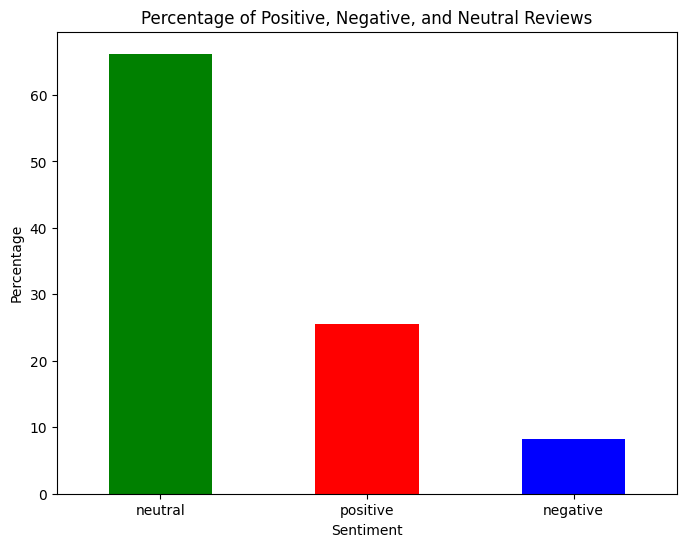

In [100]:
import matplotlib.pyplot as plt

# Define function to classify sentiment
def classify_sentiment(score):
    if score >= 0.2:
        return 'positive'
    elif score <= -0.2:
        return 'negative'
    else:
        return 'neutral'

# Apply sentiment classification to each review
data['sentiment_class'] = data['sentiment'].apply(classify_sentiment)

# Calculate percentage of each sentiment class
sentiment_counts = data['sentiment_class'].value_counts(normalize=True) * 100

# Plot the percentage of positive, negative, and neutral reviews
plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Percentage of Positive, Negative, and Neutral Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()